In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from typing import TypedDict, Annotated, Optional, Literal, List
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langgraph.graph.message import add_messages  ## Optimized reducer with BaseMessage Class
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from my_llm import *
from langchain_core.runnables import RunnableConfig
import sqlite3
import operator
from IPython.display import display, Image
from datetime import datetime
from pydantic import BaseModel, Field

from langchain_tavily import TavilySearch
from dotenv import load_dotenv

load_dotenv()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


True

In [3]:
TAVILY_API_KEY =  os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

In [25]:
import re
import unicodedata

import re
import unicodedata
from pathlib import Path

def generate_filename(title: str) -> str:
    # Normalize unicode
    title = unicodedata.normalize('NFKD', title).encode('ascii', 'ignore').decode('ascii')
    
    # Lowercase
    title = title.lower()
    
    # Replace anything not a-z or 0-9 with underscore
    title = re.sub(r'[^a-z0-9]+', '_', title)
    
    # Remove extra underscores
    title = title.strip('_')
    
    if not title:
        title = "file"
    
    return f"{title}.md"


# Example
title = "Indian Monuments: A Journey Through Time"
file_name = generate_filename(title)
print(file_name)

indian_monuments_a_journey_through_time.md


In [4]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(description="What to cover")
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

class RouterDecision(BaseModel):
    needs_research: bool = Field(description="Whether internet search is required for the task or not")
    mode: Literal["closed_book","hybrid","open_book"] = Field(description="Depending on the topic, decide whether internet search is required fully or partly or not at all")
    queries: List[str] = Field(description=f"In case internet search is required, what queries to search for considering today's date {datetime.now().strftime('%Y-%m-%d')}")


class Evidence_item(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = Field(None, description="When was the article published? If available")
    snippet: Optional[str] = Field(None, description="A brief snippet from the article that is relevant to the task")
    source: Optional[str] = Field(None, description="Source of the evidence, e.g., website name or database name")

class EvidencePackage(BaseModel):
    evidence_items: List[Evidence_item]

class Plan(BaseModel):
    blog_title: str = Field(description="Blog Title in less than 10 words")
    tasks: list[Task] = Field(description="List of tasks to cover in the blog")


In [5]:
class State(TypedDict):
    topic: str

    ### Routing/ Research related
    mode: Literal["closed_book","hybrid","open_book"] = Field(description="Depending on the topic, decide whether internet search is required fully or partly or not at all")
    needs_research: bool = Field(description="Whether internet search is required for the task or not")
    queries: List[str] = Field(description="In case internet search is required")
    evidence: EvidencePackage = Field(description="Evidence collected from the internet search")
    plan: Plan ## Created by Orchestrator Agent


    ## Final content related
    sections : Annotated[list[tuple], operator.add] = Field(description="Stores the output of worker nodes for the tasks provided") ## Created by Orchestrator Agent, we have added a reducer function to it which will add the output of worker nodes to this list
    final: str = Field(description="Final blog content created by Orchestrator Agent")
    
    ## Refining related
    approved: Optional[bool] = Field(description="Approval status of the final blog content")
    feedback: Optional[str] = Field(description="Feedback provided by the user in case the content is not approved")

In [29]:
### Given topic name first check wheter internet research is required or not using a Routing Agent.

def RoutingAgent(state: State):
    message = [
        SystemMessage(content="Given a blog topic, decide whether internet research is required to create a good blog plan and content. If yes, provide relevant search queries. Always provide reasoning for your decision."),
        HumanMessage(content=f"Blog Topic: {state['topic']}")
    ]
    
    decision = model.with_structured_output(RouterDecision).invoke(message)
    
    return {
        "mode": decision.mode,
        "needs_research": decision.needs_research,
        "queries": decision.queries
    }

def ResearchAgent(state: State):
    search_tool = TavilySearch(
        max_results=2,
        topic="general",
    )

    evidence_items = []

    queries = state.get("queries", [])

    for query in queries:
        results = search_tool.invoke(query)

        for item in results.get("results", []):
            evidence = Evidence_item(
                title=item.get("title", ""),
                url=item.get("url", ""),
                published_at=item.get("published_date"),
                snippet=item.get("content"),
                source=item.get("url", "").split("/")[2] if item.get("url") else None
            )
            evidence_items.append(evidence)

    # ✅ Wrap into EvidencePackage
    return {"evidence": EvidencePackage(evidence_items=evidence_items)}

def route_for_research(state):
    if state["needs_research"]:
        return "research"
    else:
        return "orchestrate"




def Orchestrator(state: State):
    if state["needs_research"]:
        message = [SystemMessage(content="Create a blog plan with 5-7 sections on the following topic. Use the provided internet search results to create a better plan."), 
        HumanMessage(content=f"""
        Topic: {state['topic']}
        Evidence: {state['evidence']}
        """)]
        
    else:
        message = [SystemMessage(content="Create a blog plan with 5-7 sections on the following topic."), 
                HumanMessage(content=f"Topic: {state['topic']}")]

    plan = model.with_structured_output(Plan).invoke(
        message
    )
    return {"plan": plan}


def UserFeedback(state: State):
    print("\nGenerated Plan:\n", state["plan"])
    
    user_input = input(
        "\nType:\n"
        "- 'yes' to approve\n"
        "- 'no' to retry\n"
        "- OR give feedback (what to add/remove/change):\n"
    )
    
    if user_input.lower() == "yes":
        return {"approved": True, "feedback": None}
    if user_input.lower() == "no":
        return {"approved": False, "feedback": None}
    else:
        print("\nUser Feedback:\n", user_input)
        return {"approved": False, "feedback": user_input}
    

def RefinePlan(state: State):
    message = [
        SystemMessage(content="Improve the blog plan based on user feedback."),
        HumanMessage(content=f"""
        Original Topic: {state['topic']}
        
        Current Plan:
        {state['plan']}
        
        User Feedback:
        {state['feedback']}
        
        Modify the plan accordingly. If user feedback is null, try to improve the plan by trying again.
        """)
    ]
    
    new_plan = model.with_structured_output(Plan).invoke(message)
    
    return {"plan": new_plan}

def route_after_feedback(state):
    if state["approved"]:
        return fanout_section_writing(state)  # ✅ returns Send list
    else:
        return "refine"


def fanout_section_writing(state: State):
    return [
        Send("worker", {
            "task": task,
            "topic": state["topic"],
            "plan": state["plan"],
            "evidence": state["evidence"],  # ✅ Pass evidence to worker if available
            "index": i  # ✅ IMPORTANT
        })
        for i, task in enumerate(state["plan"].tasks)
    ]


def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    index = payload["index"]
    
    message = [
        SystemMessage(content="Write a clean Markdown section for a blog."),
        HumanMessage(content=f"""
Blog Topic: {topic}
Blog Title: {plan.blog_title}
Task Title: {task.title}
Task Brief: {task.brief}

Use these internet search results as evidence if available: {payload["evidence"]} (if required)
Return only the section content in Markdown. Use ## for the task title and do not mention about the blog title in the section content.
 Also mention the citations or source link  at the section level.
""")
    ]
    
    section_content = model.invoke(message).content.strip()
    
    return {"sections": [(index, section_content)]}  # ✅ FIX

from pathlib import Path

def reducer(state: State) -> State:
    title = state["plan"].blog_title
    
    # ✅ Sort sections by index
    sorted_sections = sorted(state["sections"], key=lambda x: x[0])
    
    ordered_content = [content for _, content in sorted_sections]
    
    body = "\n\n".join(ordered_content).strip()

    final_content = f"# {title}\n\n{body}"

    folder = "./generated_articles"

    file_name = generate_filename(title)
    print(title, file_name)
    print(f"\nSaving the generated blog to {folder}/{file_name}...\n")
    output_path = Path(folder)/file_name
    output_path.parent.mkdir(parents=True, exist_ok=True)

    output_path.write_text(final_content, encoding="utf-8")

    return {"final": final_content}

In [30]:
# graph = StateGraph(State)

# graph.add_node("RoutingAgent", RoutingAgent)
# graph.add_node("ResearchAgent", ResearchAgent)
# graph.add_node("Orchestrator", Orchestrator)

# graph.set_entry_point("RoutingAgent")
# graph.add_conditional_edges("RoutingAgent", route_for_research, {
#     "research": "ResearchAgent",
#     "orchestrate": "Orchestrator"
# })


# graph.add_edge("ResearchAgent", "Orchestrator")
# graph.set_finish_point("Orchestrator")

# workflow = graph.compile()

In [31]:
# display(Image(workflow.get_graph().draw_mermaid_png()))

In [32]:
# response = workflow.invoke({
#     "topic": "Recent trends of Agentic AI and its impact in the industries."
#     })

In [33]:
# response['plan'].tasks

In [34]:
graph = StateGraph(State)

graph = StateGraph(State)

graph.add_node("RoutingAgent", RoutingAgent)
graph.add_node("ResearchAgent", ResearchAgent)
graph.add_node("Orchestrator", Orchestrator)


graph.add_node("user_feedback", UserFeedback)
graph.add_node("refine", RefinePlan)

graph.add_node("worker", worker)
graph.add_node("reducer", reducer)
graph.add_node("fanout", fanout_section_writing)

graph.set_entry_point("RoutingAgent")
graph.add_conditional_edges("RoutingAgent", route_for_research, {
    "research": "ResearchAgent",
    "orchestrate": "Orchestrator"
})


graph.add_edge("ResearchAgent", "Orchestrator")

# Plan → feedback
graph.add_edge("Orchestrator", "user_feedback")

graph.add_conditional_edges(
    "user_feedback",
    route_after_feedback
)

graph.add_edge("refine", "user_feedback")

# Workers → reducer
graph.add_edge("worker", "reducer")

# End
graph.add_edge("reducer", END)

workflow = graph.compile()

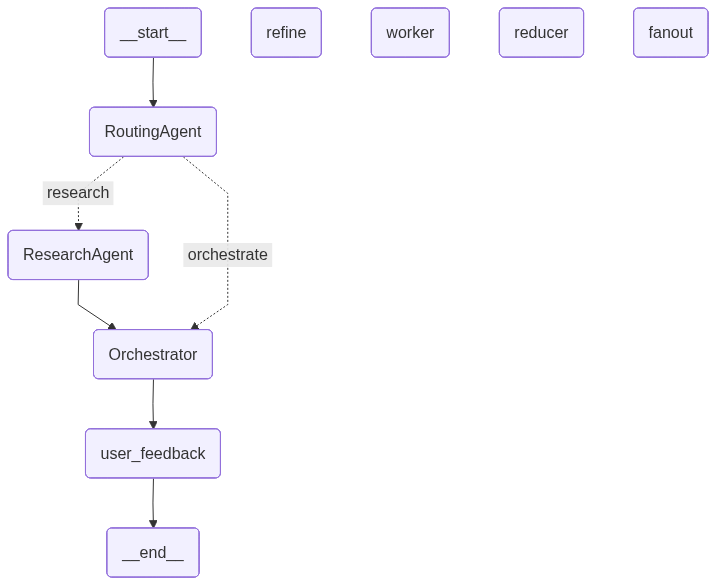

In [35]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [37]:
workflow.invoke({'topic': 'Story of Indian monuments till 21st century'})

c:\Users\shivo\Projects\Agentic\Agentic_Learning\langenv\lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(needs_rese...n of Indian monuments']), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(



Generated Plan:
 blog_title='Journey of Indian Monuments Through the Centuries' tasks=[Task(id=1, title='Introduction & Historical Context', brief="Provide an overview of India's rich historical and cultural legacy, highlighting the significance of monuments in shaping the nation's narrative from ancient times to the 21st century.", requires_research=True, requires_citations=True, requires_code=False), Task(id=2, title='Ancient Foundations & Temple Architecture', brief="Discuss the evolution of India's ancient monuments, with a focus on early temple architecture, Vaastu Shastra principles, and the influences of various dynasties as evidenced by historical texts and scholarly research.", requires_research=True, requires_citations=True, requires_code=False), Task(id=3, title='Medieval and Colonial Influences', brief='Examine the transformation of monument architecture during the medieval period and under colonial rule, exploring how artistic, religious, and political influences contribu

c:\Users\shivo\Projects\Agentic\Agentic_Learning\langenv\lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(blog_title='Journey ..., requires_code=False)]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


Journey of Indian Monuments Through the Centuries journey_of_indian_monuments_through_the_centuries.md

Saving the generated blog to ./generated_articles/journey_of_indian_monuments_through_the_centuries.md...



{'topic': 'Story of Indian monuments till 21st century',
 'mode': 'hybrid',
 'needs_research': True,
 'queries': ['History and evolution of Indian monuments from ancient times to the 21st century',
  'Significant Indian monuments and their stories, including modern additions',
  'Cultural and historical significance of Indian monuments in contemporary times',
  'Impact of modern architecture and preservation efforts on Indian heritage sites',
  'Recent updates and developments in the preservation and renovation of Indian monuments'],
 'evidence': EvidencePackage(evidence_items=[Evidence_item(title='Evolution of Indian Temple Architecture: From Ancient Foundations ...', url='https://indianetzone.wordpress.com/2025/02/19/evolution-of-indian-temple-architecture-from-ancient-foundations-to-modern-marvels/', published_at=None, snippet='Temple architecture in India has evolved over centuries, reflecting the artistic, religious, and political influences of different periods.', source='indiane

In [19]:
file_name

'indian_monuments_a_journey_through_time.md'